# 🎵 Make music with a tiny attention model

Your first notebooks predicted a **label** from a couple of numbers (will this student be
admitted?). Then `embeddings_and_attention.ipynb` showed how a model can look at a *sequence*
and let each item **attend** to the others.

This notebook puts that idea to work on something you can actually *hear*: **chord progressions**.

The plan, top to bottom:

1. Build the 7 chords of a single key (C major) and turn them into **MIDI** notes.
2. Write down some classic **chord progressions**, and make **variations** of them.
3. Split those progressions into **training / validation / test** data — exactly like a real ML dataset.
4. Build a **tiny self-attention model** whose only job is: *given the chords so far, predict the next chord.*
5. Train it, check it on data it never saw, then let it **compose** new progressions.
6. Render the result to a `.mid` file **and** play it right here in the notebook.

Nothing is downloaded and nothing is huge — every piece is small enough to read. Run the cells in order.

> One-time setup: this notebook needs the `pretty_midi` library. From a terminal in the repo run
> `uv add pretty_midi` and restart this kernel. (Everything else — `torch`, `numpy`, `matplotlib`,
> `ipywidgets` — you already have.)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import pretty_midi
from IPython.display import Audio, display
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

plt.rcParams["figure.figsize"] = (8, 4)

# One seed so your run matches the text (change it and everything downstream shifts).
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

SR = 22050  # audio sample rate for the in-notebook synth
print("Ready. torch", torch.__version__, "| numpy", np.__version__)

Ready. torch 2.12.1 | numpy 2.5.0


## 1. Music in one key

We keep life simple and stay in **C major**. A *major scale* is just seven notes; on a piano,
C major is the white keys. In MIDI, every note is a number — middle C (`C4`) is **60**, and each
step up by a semitone adds 1.

The seven notes of C major (starting at C4) are these MIDI numbers:

`C=60  D=62  E=64  F=65  G=67  A=69  B=71`

A **chord** is a few notes played together. A *triad* stacks three scale notes: a root, the note
two scale-steps up (the "third"), and two more up (the "fifth"). Build a triad starting on each
scale note and you get the **seven diatonic chords** of the key — the whole harmonic vocabulary
we'll let the model play with.

Musicians name them with Roman numerals: uppercase = major-ish, lowercase = minor-ish,
`vii°` = diminished.

In [3]:
# The C-major scale as MIDI note numbers, repeated over two octaves so we can always
# stack a triad without running off the top.
SCALE_DEGREES = [0, 2, 4, 5, 7, 9, 11]          # semitone offsets of a major scale
C4 = 60
SCALE = [C4 + off for off in SCALE_DEGREES]      # C4..B4
SCALE = SCALE + [n + 12 for n in SCALE]          # ...plus the next octave

# Human-readable names for the 7 diatonic chords, index 0..6.
DEGREE_NAMES = ["I", "ii", "iii", "IV", "V", "vi", "vii°"]
VOCAB_SIZE = len(DEGREE_NAMES)

def chord_to_pitches(degree):
    '''Turn a scale degree (0..6) into the 3 MIDI pitches of its triad.'''
    root, third, fifth = degree, degree + 2, degree + 4  # stack in thirds
    return [SCALE[root], SCALE[third], SCALE[fifth]]

for d, name in enumerate(DEGREE_NAMES):
    print(f"{name:>4}  ->  MIDI pitches {chord_to_pitches(d)}")

   I  ->  MIDI pitches [60, 64, 67]
  ii  ->  MIDI pitches [62, 65, 69]
 iii  ->  MIDI pitches [64, 67, 71]
  IV  ->  MIDI pitches [65, 69, 72]
   V  ->  MIDI pitches [67, 71, 74]
  vi  ->  MIDI pitches [69, 72, 76]
vii°  ->  MIDI pitches [71, 74, 77]


## 2. Hear a single chord

Before any machine learning, let's make sure we can actually turn chords into sound.

Two little helpers do all the audio work in this notebook:

- `synth(...)` is a **hand-built synthesizer**: for each note it makes a sine wave at the right
  frequency, shapes its volume with a quick fade-in/fade-out (an *envelope*, so it doesn't click),
  adds them up, and hands back a numpy waveform that `IPython.display.Audio` can play. No extra
  software needed.
- `render_midi(...)` writes a real **`.mid` file** with `pretty_midi` that you can open in any DAW
  or media player.

A MIDI pitch `p` maps to a frequency with `440 * 2**((p - 69) / 12)` (note 69 = A4 = 440 Hz).

In [4]:
def midi_to_freq(p):
    return 440.0 * 2 ** ((p - 69) / 12)

def envelope(n, sr):
    '''A simple fade-in / fade-out so notes don't click. Length n samples.'''
    env = np.ones(n)
    edge = int(0.02 * sr)                    # 20 ms ramps
    if edge > 0 and n >= 2 * edge:
        env[:edge] = np.linspace(0, 1, edge)
        env[-edge:] = np.linspace(1, 0, edge)
    return env

def synth(pitches, dur=0.6, sr=SR):
    '''Additive sine synth: sum one gently-shaped sine per pitch -> waveform.'''
    n = int(dur * sr)
    t = np.linspace(0, dur, n, endpoint=False)
    wave = np.zeros(n)
    for p in pitches:
        wave += np.sin(2 * np.pi * midi_to_freq(p) * t)
    wave *= envelope(n, sr)
    peak = np.max(np.abs(wave))
    return wave / peak * 0.9 if peak > 0 else wave  # normalise, leave a little headroom

def sequence_to_wave(degrees, dur=0.6, sr=SR):
    '''Play a list of chord degrees one after another.'''
    return np.concatenate([synth(chord_to_pitches(d), dur, sr) for d in degrees])

# Play the tonic chord (I) on its own.
display(Audio(synth(chord_to_pitches(0)), rate=SR))

## 3. Chord progressions and variations

Music is mostly not random chords — it's chords in **familiar orders**. A *progression* is a
short sequence of chords that sounds like it belongs together. A handful of these power a huge
amount of pop, folk, and classical music.

We write each one as a list of degree indices (remember `I`=0, `ii`=1, … `vii°`=6):

| Progression        | Degrees        | Where you've heard it |
|--------------------|----------------|-----------------------|
| I–IV–V–I           | `[0,3,4,0]`    | countless folk/rock tunes |
| ii–V–I             | `[1,4,0]`      | the backbone of jazz |
| I–V–vi–IV          | `[0,4,5,3]`    | the "four-chord pop song" |
| I–vi–IV–V          | `[0,5,3,4]`    | 1950s doo-wop |
| vi–IV–I–V          | `[5,3,0,4]`    | modern pop ballads |
| I–iii–IV–V         | `[0,2,3,4]`    | bright, rising feel |

To give the model more than a handful of examples we make **variations**: rotate a progression so
it starts on a different chord, repeat it, or swap in a chord that plays a similar role (a light,
in-key substitution). None of this leaves C major — it just gives us a richer, more realistic
dataset to learn from.

In [5]:
BASE_PROGRESSIONS = [
    [0, 3, 4, 0],     # I  IV V  I
    [1, 4, 0],        # ii V  I
    [0, 4, 5, 3],     # I  V  vi IV
    [0, 5, 3, 4],     # I  vi IV V
    [5, 3, 0, 4],     # vi IV I  V
    [0, 2, 3, 4],     # I  iii IV V
]

# Chords that can stand in for one another (share notes / harmonic role).
SUBSTITUTES = {0: [5], 3: [1], 4: [6], 5: [0], 1: [3], 2: [5]}

def rotations(prog):
    return [prog[i:] + prog[:i] for i in range(len(prog))]

def substituted(prog):
    '''Every one-chord in-key substitution of a progression.'''
    out = []
    for i, ch in enumerate(prog):
        for sub in SUBSTITUTES.get(ch, []):
            out.append(prog[:i] + [sub] + prog[i + 1:])
    return out

def make_variations(prog):
    variants = set()
    for r in rotations(prog):
        variants.add(tuple(r))            # rotated
        variants.add(tuple(r + r))        # played twice
        for s in substituted(r):
            variants.add(tuple(s))        # one-chord substitution
    return [list(v) for v in variants]

progressions = []
for base in BASE_PROGRESSIONS:
    progressions.extend(make_variations(base))

# de-duplicate while keeping order deterministic
progressions = [list(p) for p in dict.fromkeys(tuple(p) for p in progressions)]
print(f"{len(BASE_PROGRESSIONS)} base progressions -> {len(progressions)} total after variations")

# Hear the famous four-chord pop progression:
display(Audio(sequence_to_wave([0, 4, 5, 3] * 2), rate=SR))

6 base progressions -> 99 total after variations


## 4. Build the dataset — and split it properly

The model's task is **next-chord prediction**: show it the chords so far, ask for the one that
comes next. So from every progression we slide a window of length `SEQ_LEN` along it: the window
is the **input**, and the chord right after it is the **target**.

Now the important ML habit: we **split the data** so we can trust our results.

- **Training set** — the model learns from these.
- **Validation set** — we peek during training to see if it's still improving (and not just
  memorising).
- **Test set** — locked away until the very end, to measure how well it does on progressions it
  has *never* seen.

Crucially we split by **whole progression**, not by individual windows. If windows from the same
progression leaked into both train and test, the test score would be flattering nonsense.

In [6]:
SEQ_LEN = 3   # how many previous chords the model sees before guessing the next

# Shuffle whole progressions, then carve 70% / 15% / 15%.
order = np.random.permutation(len(progressions))
n = len(order)
n_train, n_val = int(0.70 * n), int(0.15 * n)
split = {
    "train": [progressions[i] for i in order[:n_train]],
    "val":   [progressions[i] for i in order[n_train:n_train + n_val]],
    "test":  [progressions[i] for i in order[n_train + n_val:]],
}

def windows(progs, seq_len=SEQ_LEN):
    '''Turn a list of progressions into (input_window, next_chord) tensors.'''
    X, y = [], []
    for p in progs:
        if len(p) <= seq_len:
            continue
        for i in range(len(p) - seq_len):
            X.append(p[i:i + seq_len])
            y.append(p[i + seq_len])
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

Xtr, ytr = windows(split["train"])
Xva, yva = windows(split["val"])
Xte, yte = windows(split["test"])

for name, X in [("train", Xtr), ("val", Xva), ("test", Xte)]:
    print(f"{name:>5}: {len(split[name]):>3} progressions -> {len(X):>4} examples")
print("\nExample -> given", [DEGREE_NAMES[c] for c in Xtr[0].tolist()],
      "predict", DEGREE_NAMES[ytr[0].item()])

train:  69 progressions ->  100 examples
  val:  14 progressions ->   18 examples
 test:  16 progressions ->   39 examples

Example -> given ['I', 'iii', 'IV'] predict V


## 5. Chords as tokens and embeddings

This is exactly the move from `embeddings_and_attention.ipynb`. Each chord is already a small
integer (a **token**, 0..6). But an integer alone says nothing about how chords *relate*.

So we give every chord a short learned vector — its **embedding**. Chords that behave similarly can
drift close together in this space as training goes on. We also add a **positional embedding**, one
per slot in the window, because *where* a chord sits in the progression matters (a `V` leading home
to `I` is not the same as a `V` sitting at the start).

We don't build these by hand this time — `nn.Embedding` is just a lookup table of vectors that
learns along with everything else. The attention model below is where they get used.

In [7]:
EMBED_DIM = 16   # size of each chord's learned vector (a "knob to play with")

demo_embed = nn.Embedding(VOCAB_SIZE, EMBED_DIM)
print("Embedding table shape:", tuple(demo_embed.weight.shape), "(one row per chord)")
print("Vector for chord I before training:\n", demo_embed(torch.tensor(0)).detach().numpy().round(2))

Embedding table shape: (7, 16) (one row per chord)
Vector for chord I before training:
 [-1.13 -1.15 -0.25 -0.43  0.85  0.69 -0.32 -2.12  0.32 -1.26  0.35  0.31
  0.12  1.24  1.12 -0.25]


## 6. A tiny attention model

Here's the whole model, and it's small enough to read in one sitting:

1. **Embed** each chord in the window and **add** its positional embedding.
2. One block of **self-attention**: every chord looks at the others in the window and mixes in
   what's relevant. We use a **causal mask** so a chord can only attend to itself and the chords
   *before* it — no peeking at the future, which would be cheating for a predictor.
3. A small **feed-forward** layer to let it reshape those mixed features.
4. Take the representation at the **last** position and run it through a **linear head** to get one
   score per possible next chord (7 numbers → a probability with `softmax`).

That's a miniature version of the same architecture behind large language models — just for chords
instead of words.

In [8]:
class ChordAttention(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 seq_len=SEQ_LEN, n_heads=2):
        super().__init__()
        self.chord_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(seq_len, embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim), nn.ReLU(),
            nn.Linear(4 * embed_dim, embed_dim),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)
        self.seq_len = seq_len

    def forward(self, x):                      # x: (batch, seq_len) of chord tokens
        positions = torch.arange(x.size(1))
        h = self.chord_embed(x) + self.pos_embed(positions)   # add position info
        # causal mask: True = "not allowed to look here" (the future).
        mask = torch.triu(torch.ones(x.size(1), x.size(1), dtype=torch.bool), diagonal=1)
        attended, _ = self.attn(h, h, h, attn_mask=mask)
        h = self.norm1(h + attended)           # residual + normalise
        h = self.norm2(h + self.ff(h))         # residual + normalise
        return self.head(h[:, -1, :])          # scores for the next chord

model = ChordAttention()
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal learnable parameters: {n_params}")

ChordAttention(
  (chord_embed): Embedding(7, 16)
  (pos_embed): Embedding(3, 16)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
  )
  (ff): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
  )
  (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
  (head): Linear(in_features=16, out_features=7, bias=True)
)

Total learnable parameters: 3559


## 7. Train it

Standard training loop, just like the earlier PyTorch notebooks:

- **Cross-entropy loss** — the right loss when you're choosing one class (here, one of 7 chords)
  out of many.
- **Adam** nudges the weights downhill.
- Each epoch we record loss on **train** *and* on **validation**, and plot both.

Watch the two curves. Because our dataset is *tiny* (only ~100 training examples), you'll likely
see the classic shape of **overfitting**: train loss keeps sliding down toward zero while the
validation curve bottoms out early and then creeps back **up**. That gap is the model starting to
*memorise* the training progressions instead of learning the general grammar. It's not a bug — it's
the single most important thing to be able to spot, and here you can watch it happen live. `EPOCHS`,
`EMBED_DIM`, and the dataset size are the knobs that push it around.

Everything runs on the CPU in a second or two — the model is tiny.

epoch   0  train 2.003  val 1.674
epoch  50  train 0.432  val 1.159
epoch 100  train 0.394  val 1.652
epoch 150  train 0.392  val 1.918
epoch 200  train 0.390  val 2.060
epoch 250  train 0.390  val 2.051
epoch 299  train 0.389  val 2.169


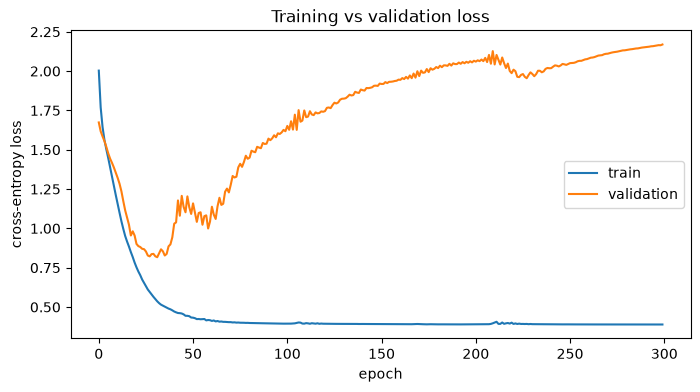

In [9]:
EPOCHS = 300
LR = 0.01

model = ChordAttention()
opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()

train_losses, val_losses = [], []
for epoch in range(EPOCHS):
    model.train()
    opt.zero_grad()
    loss = loss_fn(model(Xtr), ytr)
    loss.backward()
    opt.step()

    model.eval()
    with torch.no_grad():
        vloss = loss_fn(model(Xva), yva)
    train_losses.append(loss.item())
    val_losses.append(vloss.item())
    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:>3}  train {loss.item():.3f}  val {vloss.item():.3f}")

fig, ax = plt.subplots()
ax.plot(train_losses, label="train")
ax.plot(val_losses, label="validation")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
ax.set_title("Training vs validation loss"); ax.legend()
plt.show()

## 8. Check it on the test set

Now we open the box we locked earlier. The **test set** is progressions the model never trained on
and we never looked at while tuning. Its loss and **accuracy** (how often the top guess is exactly
right) are our honest estimate of how well it learned the *grammar* of these progressions.

A caveat worth remembering: chord prediction is genuinely ambiguous — after `I` several chords are
perfectly good. So don't expect 100%. What we want is clearly **better than random** (random over 7
chords ≈ 14%) and test numbers **in the same ballpark** as validation, which means it generalised
rather than memorised.

In [10]:
def evaluate(X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        loss = loss_fn(logits, y).item()
        acc = (logits.argmax(1) == y).float().mean().item()
    return loss, acc

for name, X, y in [("train", Xtr, ytr), ("val", Xva, yva), ("test", Xte, yte)]:
    loss, acc = evaluate(X, y)
    print(f"{name:>5}:  loss {loss:.3f}   accuracy {acc:5.1%}")
print(f"\n(random guessing would be about {1/VOCAB_SIZE:.1%})")

train:  loss 0.389   accuracy 82.0%
  val:  loss 2.169   accuracy 72.2%
 test:  loss 1.583   accuracy 71.8%

(random guessing would be about 14.3%)


## 9. Let it compose

Prediction becomes **generation** when we feed the model's own output back in:

1. Start from a **seed** chord (or a few).
2. Ask the model for scores over the next chord, turn them into probabilities, and **sample** one.
3. Append it, slide the window, repeat.

The **temperature** knob controls the mood of the sampling:

- low (`≈0.3`) → cautious, it keeps picking the most likely chord (safe, repetitive);
- around `1.0` → balanced;
- high (`≈1.5`) → adventurous and surprising (sometimes a bit wild).

We decode the chords back to triads, save a `.mid` file, and play it.

In [14]:
def generate(seed=(0,), length=8, temperature=1.0):
    '''Autoregressively sample a progression of `length` chords from a seed.'''
    seq = list(seed)
    model.eval()
    for _ in range(length - len(seq)):
        window = seq[-SEQ_LEN:]
        # left-pad short windows with the tonic so the input is always SEQ_LEN long
        while len(window) < SEQ_LEN:
            window = [0] + window
        x = torch.tensor([window], dtype=torch.long)
        with torch.no_grad():
            logits = model(x)[0] / temperature
        probs = F.softmax(logits, dim=-1).numpy()
        seq.append(int(np.random.choice(VOCAB_SIZE, p=probs)))
    return seq

def render_midi(degrees, path="generated.mid", beat=0.5):
    '''Write a chord progression to a .mid file (each chord = one beat).'''
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)   # Acoustic Grand Piano
    for i, d in enumerate(degrees):
        start, end = i * beat, (i + 1) * beat
        for pitch in chord_to_pitches(d):
            piano.notes.append(pretty_midi.Note(velocity=90, pitch=pitch,
                                                 start=start, end=end))
    pm.instruments.append(piano)
    pm.write(path)
    return path

np.random.seed(SEED)                             # reproducible composition
tune = generate(seed=(0,), length=8, temperature=0.9)
print("Composed:", [DEGREE_NAMES[d] for d in tune])
path = render_midi(tune)
print("Wrote", path)
display(Audio(sequence_to_wave(tune), rate=SR))

Composed: ['I', 'IV', 'V', 'I', 'iii', 'IV', 'V', 'I']
Wrote generated.mid


## 10. 🎛️ Compose interactively

Turn the knobs and hear the model react. Each move regenerates a progression and plays it:

- **seed** — the chord it starts on;
- **length** — how many chords to write;
- **temperature** — safe & predictable (left) vs. adventurous (right).

Try the same seed at temperature 0.3, then 1.5, and listen to how the model's "confidence" changes
the music.

In [ ]:
@interact(
    seed=Dropdown(options=[(n, i) for i, n in enumerate(DEGREE_NAMES)], value=0, description="seed"),
    length=IntSlider(min=4, max=16, step=1, value=8, description="length"),
    temperature=FloatSlider(min=0.2, max=1.8, step=0.1, value=0.9, description="temp"),
)
def compose(seed, length, temperature):
    tune = generate(seed=(seed,), length=length, temperature=temperature)
    print("Chords:", " ".join(DEGREE_NAMES[d] for d in tune))
    render_midi(tune, path="generated.mid")
    display(Audio(sequence_to_wave(tune), rate=SR))

interactive(children=(Dropdown(description='seed', options=(('I', 0), ('ii', 1), ('iii', 2), ('IV', 3), ('V', …

## 11. Recap — and where this goes next

You built a complete little music-ML pipeline:

- **represented** chords as MIDI notes and as learned **embeddings**;
- turned classic **progressions + variations** into a proper **train / validation / test** dataset,
  split by whole progression so the test score is honest;
- trained a **tiny self-attention model** to predict the next chord — the same architecture idea as
  a language model, shrunk down to something you can read end to end;
- checked it on **unseen** progressions, then let it **compose**, saving both a `.mid` file and
  audio you can play here.

Where you could take it next:

- **Melody**, not just chords — add a second stream of single notes over the harmony.
- **More keys** — transpose everything and let the model generalise across keys.
- **Richer harmony** — add seventh chords and a 12-bar blues to the vocabulary.
- **Longer memory** — grow `SEQ_LEN` (and stack a second attention block) so it can shape longer phrases.
- **Rhythm** — let chord durations vary instead of a fixed one-beat grid.

Knobs to play with above: `SEED`, `SEQ_LEN`, `EMBED_DIM`, `EPOCHS`, `LR`, and the `temperature` in
generation. Change one, rerun, and listen to what it does.